In [1]:
from astroML.datasets import generate_mu_z
from matplotlib import pyplot as plt
import numpy as np
import sklearn
from sklearn.linear_model import LinearRegression
from astroML.linear_model import PolynomialRegression
from astroML.linear_model import BasisFunctionRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import learning_curve
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from functools import partial
from astroML.linear_model.linear_regression import gaussian_basis
from astroML.linear_model import BasisFunctionRegression
from astroML.linear_model import NadarayaWatson


ModuleNotFoundError: No module named 'scipy._lib._array_api'

SUPERNOVA DISTANCES AND REDSHIFT (PART 1)

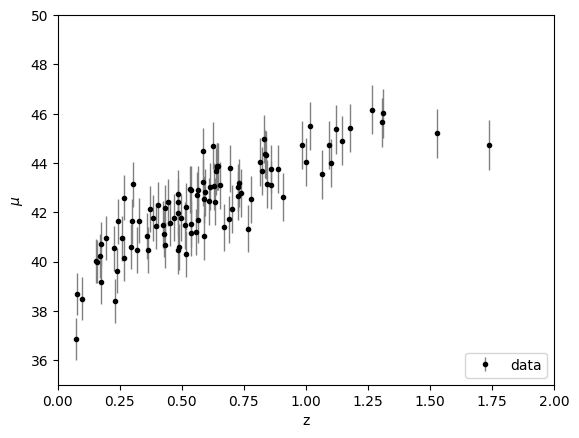

In [ ]:

z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) # YOU CANNOT CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);


Linear Fit: a0 = 4.76, a1 = 39.48


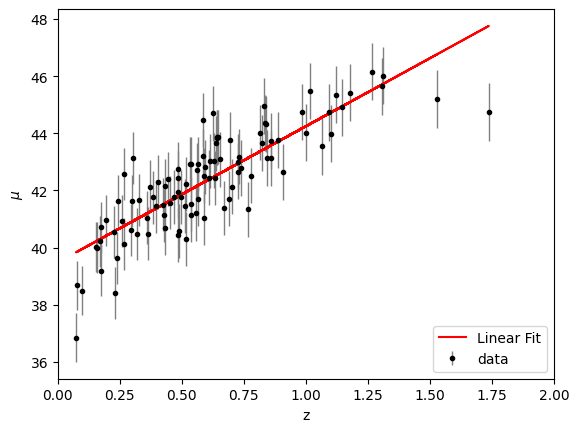

In [ ]:
# Start with a simple linear model: $\mu = a z + b$ (using sklearn's LinearRegression)
lin_reg = LinearRegression() #estimator
lin_reg.fit(z_sample.reshape(-1, 1), mu_sample, sample_weight=1/dmu**2)
mu_pred_lin = lin_reg.predict(z_sample.reshape(-1, 1))
a0 = lin_reg.coef_[0]
a1 = lin_reg.intercept_
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1,label='data')
plt.plot(z_sample, mu_pred_lin, 'r-', label='Linear Fit')
plt.xlabel("z")
plt.ylabel("$\mu$")
plt.legend(loc='lower right')   
plt.xlim(0,2)
print("Linear Fit: a0 = {:.2f}, a1 = {:.2f}".format(a0, a1))

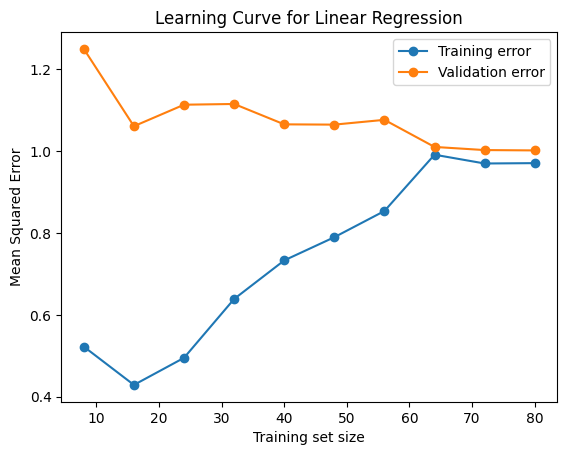

In [ ]:
# Use sklearn's learning_curve to compute the training and validation errors for different training set sizes
train_sizes, train_scores, val_scores = learning_curve(lin_reg, z_sample.reshape(-1, 1), mu_sample, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), random_state=1234, fit_params={'sample_weight': 1/dmu**2})
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)
plt.figure()
plt.plot(train_sizes, train_errors, 'o-', label='Training error')
plt.plot(train_sizes, val_errors, 'o-', label='Validation error')
plt.xlabel('Training set size')
plt.ylabel('Mean Squared Error')
plt.title('Learning Curve for Linear Regression')
plt.legend()
plt.show()

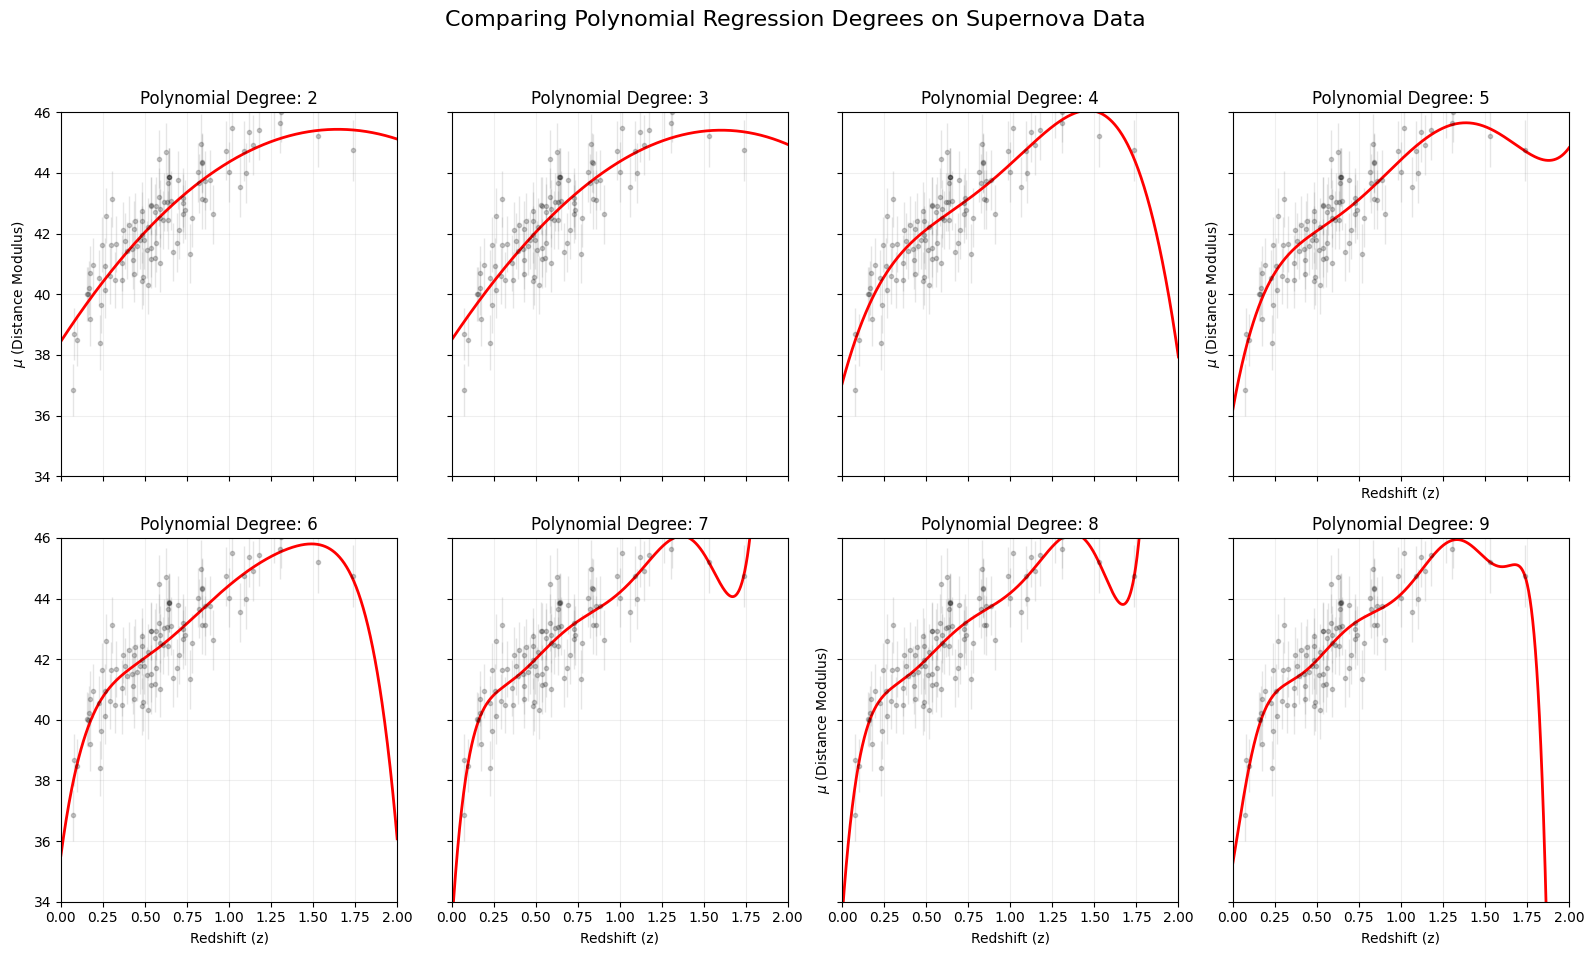

In [ ]:
# Now let's compare this linear fit with polynomial fits of degree 2 to 10 using PolynomialRegression from astroML
fig, axes = plt.subplots(2, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

# x range for plotting the fits
z_fit = np.linspace(0, 2, 1000).reshape(-1, 1)

for i, degree in enumerate(range(2, 10)):
    ax = axes[i]
    
    model = PolynomialRegression(degree=degree)
    model.fit(z_sample.reshape(-1, 1), mu_sample)
    Y_fit = model.predict(z_fit)
    
    # Plot the original data with error bars
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', 
                lw=1, alpha=0.2, label='Data' if i == 0 else "")
    
    # Plot polynomial fit
    ax.plot(z_fit, Y_fit, color='red', lw=2, label=f'Degree {degree}')
    ax.set_title(f'Polynomial Degree: {degree}', fontsize=12)
    ax.set_xlim(0, 2)
    ax.set_ylim(34, 46) # Common range for Distance Modulus
    ax.grid(alpha=0.2)

    if i >= 3:
        ax.set_xlabel("Redshift (z)")
    if i % 3 == 0:
        ax.set_ylabel(r"$\mu$ (Distance Modulus)")

plt.suptitle("Comparing Polynomial Regression Degrees on Supernova Data", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


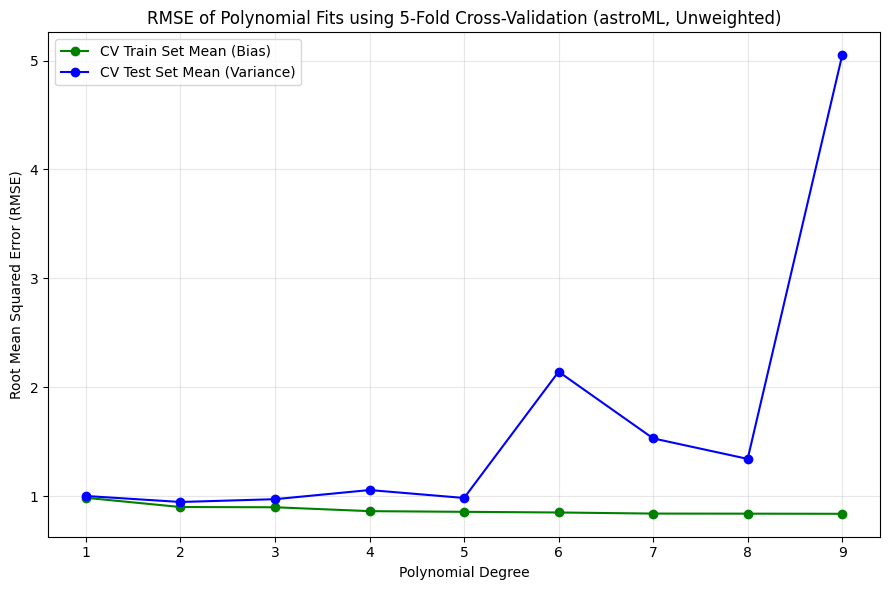

Best degree: 2


In [ ]:
# Now do a systematic comparison using cross-validation to compute the RMSE for each polynomial degree
degrees = range(1, 10)
rmse_values_train_cv = []
rmse_values_test_cv = []

for deg in degrees:
    
    model = PolynomialRegression(degree=deg)
    
    cv_results = cross_validate(
        model, 
        z_sample.reshape(-1, 1), 
        mu_sample, 
        cv=5, 
        scoring='neg_mean_squared_error',
        return_train_score=True
    )
    
    # RMSE
    rmse_train_mean = np.sqrt(np.mean(-cv_results['train_score']))
    rmse_test_mean = np.sqrt(np.mean(-cv_results['test_score']))
    
    rmse_values_train_cv.append(rmse_train_mean)
    rmse_values_test_cv.append(rmse_test_mean)

# Plot
plt.figure(figsize=(9, 6))
plt.plot(degrees, rmse_values_train_cv, marker='o', linestyle='-', color='green', label='CV Train Set Mean (Bias)')
plt.plot(degrees, rmse_values_test_cv, marker='o', linestyle='-', color='blue', label='CV Test Set Mean (Variance)')


plt.xlabel('Polynomial Degree')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('RMSE of Polynomial Fits using 5-Fold Cross-Validation (astroML, Unweighted)')
plt.xticks(degrees)
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# best model is the one with the lowest test RMSE
best = degrees[np.argmin(rmse_values_test_cv)]
print(f"Best degree: {best}")


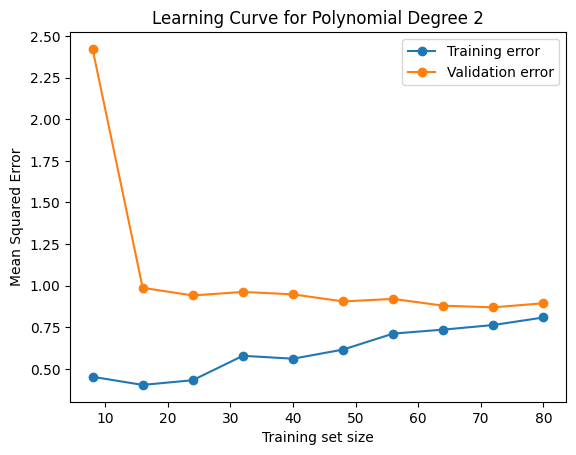

In [ ]:
# Now learning curve for the best degree
best_degree = best
best_model = PolynomialRegression(degree=best_degree)
train_sizes, train_scores, val_scores = learning_curve(best_model, z_sample.reshape(-1, 1), mu_sample, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), random_state=1234)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)
plt.figure()
plt.plot(train_sizes, train_errors, 'o-', label='Training error')
plt.plot(train_sizes, val_errors, 'o-', label='Validation error')
plt.xlabel('Training set size')
plt.ylabel('Mean Squared Error')
plt.title(f'Learning Curve for Polynomial Degree {best_degree}')
plt.legend()
plt.show()

# The two convering learning curves converge - we don't need more data to train the model

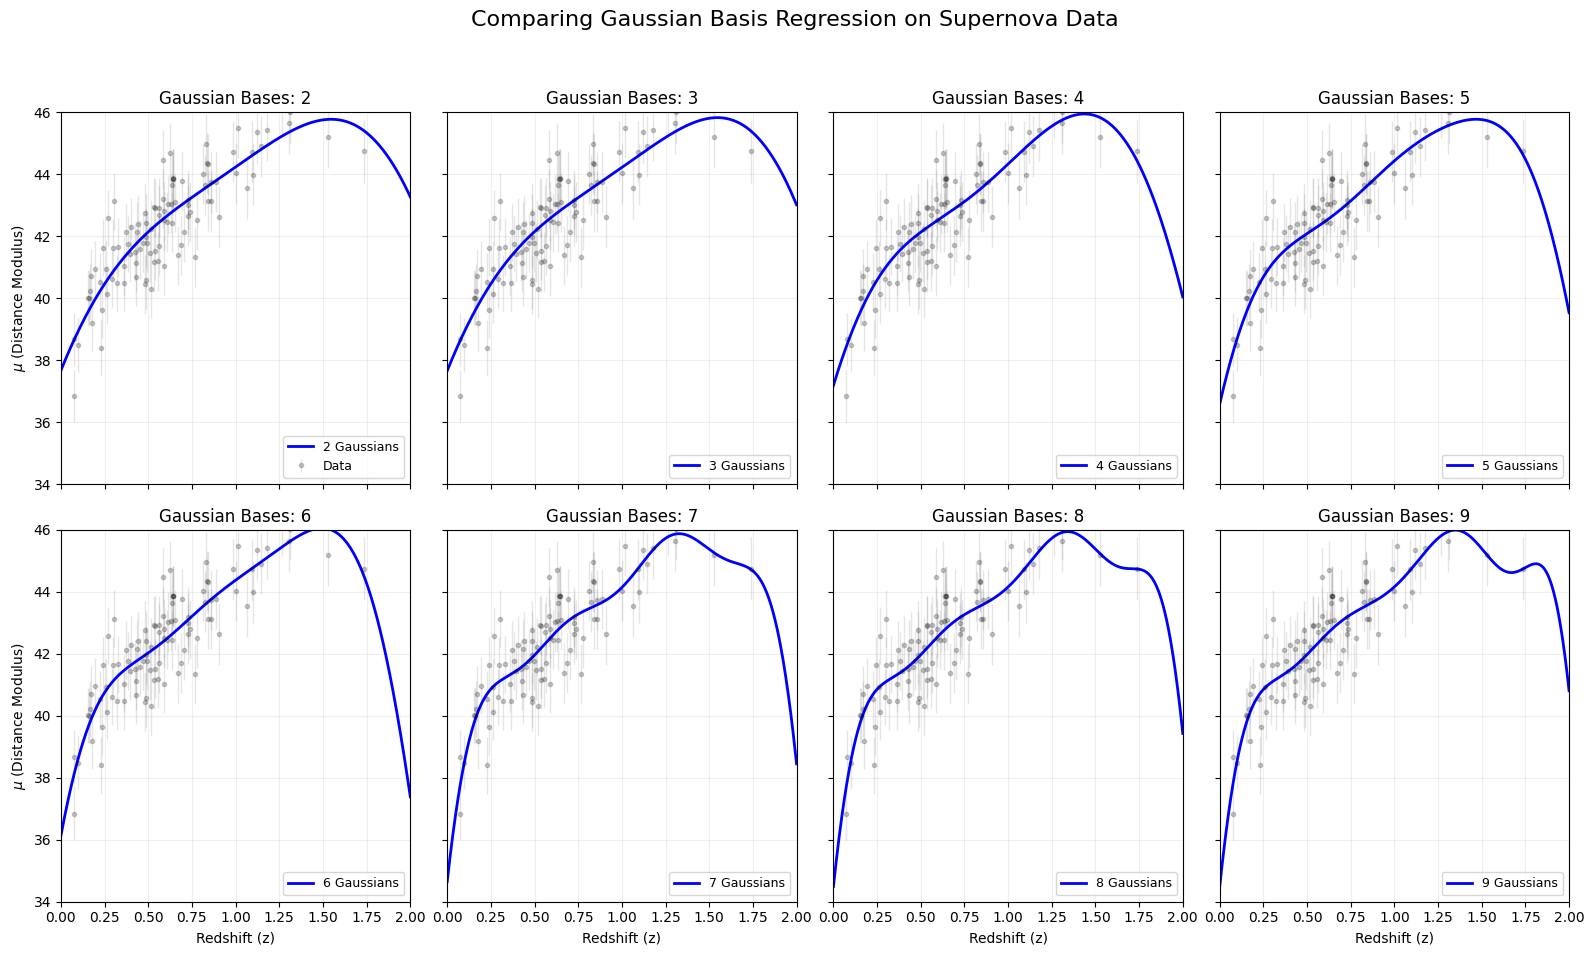

In [ ]:
# Now use basis function regression 
fig, axes = plt.subplots(2, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

z_fit = np.linspace(0, 2, 1000).reshape(-1, 1)

n_gaussians_list = range(2, 10)

for i, n_bases in enumerate(n_gaussians_list):
    ax = axes[i]
    
    # centres of gaussians and width (sigma)
    mu_centers = np.linspace(0, 2, n_bases).reshape(-1, 1)
    sigma = 2.0 / n_bases
    
    model = BasisFunctionRegression('gaussian', mu=mu_centers, sigma=sigma)
    
    model.fit(z_sample.reshape(-1, 1), mu_sample)
    Y_fit = model.predict(z_fit)
    
    
    #Plot
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', 
                lw=1, alpha=0.2, label='Data' if i == 0 else "")
    
    
    ax.plot(z_fit, Y_fit, color='blue', lw=2, label=f'{n_bases} Gaussians')
    ax.set_title(f'Gaussian Bases: {n_bases}', fontsize=12)
    ax.set_xlim(0, 2)
    ax.set_ylim(34, 46) 
    ax.grid(alpha=0.2)
    ax.legend(loc='lower right', fontsize=9)

    if i >= 4:
        ax.set_xlabel("Redshift (z)")
    if i % 4 == 0:
        ax.set_ylabel(r"$\mu$ (Distance Modulus)")

plt.suptitle("Comparing Gaussian Basis Regression on Supernova Data", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

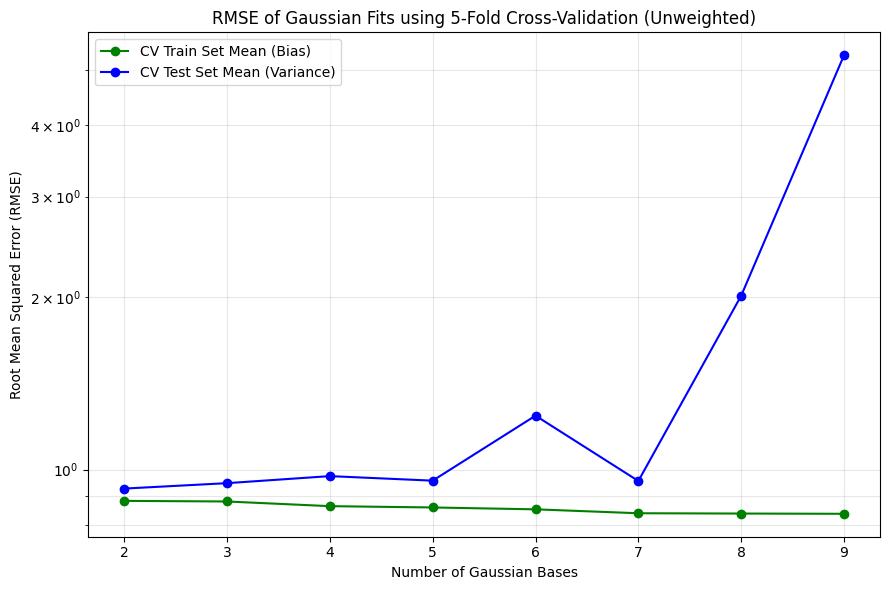

Best number of Gaussian bases: 2


In [ ]:
# Now do a systematic comparison using cross-validation to compute the RMSE for each number of gaussian bases
n_gaussians_list = range(2, 10)
rmse_values_train_cv = []
rmse_values_test_cv = []

for n_bases in n_gaussians_list:
    
    mu_centers = np.linspace(0, 2, n_bases).reshape(-1, 1)
    sigma = 2.0 / n_bases
    
    # Custom basis function with fixed mu and sigma to avoid issues with **kwargs in scikit-learn's clone
    custom_basis = partial(gaussian_basis, mu=mu_centers, sigma=sigma)
    
    model = BasisFunctionRegression(basis_func=custom_basis)

    cv_results = cross_validate(
        model, 
        z_sample.reshape(-1, 1), 
        mu_sample, 
        cv=5, 
        scoring='neg_mean_squared_error',
        return_train_score=True
    )
    
    rmse_train_mean = np.sqrt(np.mean(-cv_results['train_score']))
    rmse_test_mean = np.sqrt(np.mean(-cv_results['test_score']))
    
    rmse_values_train_cv.append(rmse_train_mean)
    rmse_values_test_cv.append(rmse_test_mean)

#Plot
plt.figure(figsize=(9, 6))
plt.plot(n_gaussians_list, rmse_values_train_cv, marker='o', linestyle='-', color='green', label='CV Train Set Mean (Bias)')
plt.plot(n_gaussians_list, rmse_values_test_cv, marker='o', linestyle='-', color='blue', label='CV Test Set Mean (Variance)')

plt.yscale('log')

plt.xlabel('Number of Gaussian Bases')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('RMSE of Gaussian Fits using 5-Fold Cross-Validation (Unweighted)')
plt.xticks(n_gaussians_list)
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# Best number of gaussian bases
best = n_gaussians_list[np.argmin(rmse_values_test_cv)]
print(f"Best number of Gaussian bases: {best}")

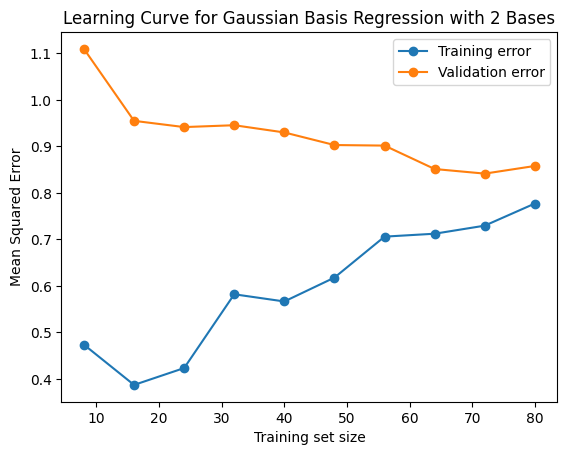

In [ ]:
# Learning curve for the best number of gaussian bases
best_n_bases = best
mu_centers = np.linspace(0, 2, best_n_bases).reshape(-1, 1)
sigma = 2.0 / best_n_bases
custom_basis = partial(gaussian_basis, mu=mu_centers, sigma=sigma)  
best_model = BasisFunctionRegression(basis_func=custom_basis)
train_sizes, train_scores, val_scores = learning_curve(best_model, z_sample.reshape(-1, 1), mu_sample, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), random_state=1234)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)
plt.figure()
plt.plot(train_sizes, train_errors, 'o-', label='Training error')
plt.plot(train_sizes, val_errors, 'o-', label='Validation error')
plt.xlabel('Training set size')
plt.ylabel('Mean Squared Error')
plt.title(f'Learning Curve for Gaussian Basis Regression with {best_n_bases} Bases')
plt.legend()
plt.show()

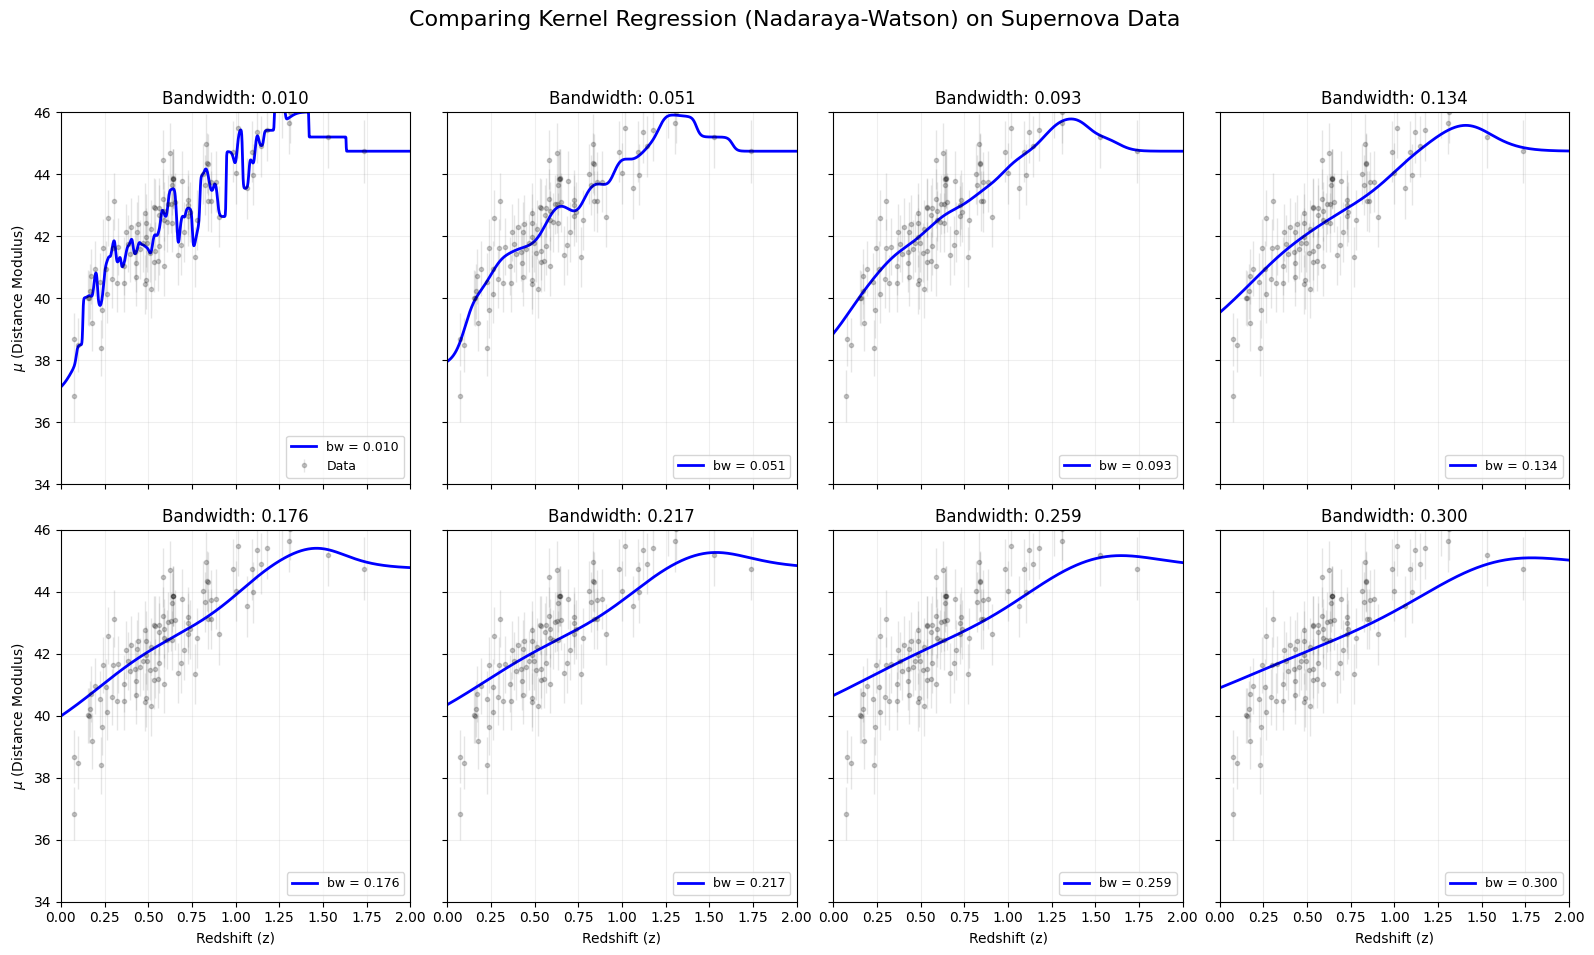

In [ ]:
# Now explore kernel regression (Nadaraya-Watson) with different bandwidths
fig, axes = plt.subplots(2, 4, figsize=(16, 10), sharex=True, sharey=True)
axes = axes.flatten()

z_fit = np.linspace(0, 2, 1000).reshape(-1, 1)

# 8 different values of bandwidth to plot
bw_list_plot = np.linspace(0.01, 0.3, 8)

for i, bw in enumerate(bw_list_plot):
    ax = axes[i]
    
    # Kernel Regression model (Nadaraya-Watson)
    model = NadarayaWatson('gaussian', h=bw)
    
    model.fit(z_sample.reshape(-1, 1), mu_sample)
    Y_fit = model.predict(z_fit)
    
    # Plot
    ax.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', 
                lw=1, alpha=0.2, label='Data' if i == 0 else "")
    
    ax.plot(z_fit, Y_fit, color='blue', lw=2, label=f'bw = {bw:.3f}')
    ax.set_title(f'Bandwidth: {bw:.3f}', fontsize=12)
    ax.set_xlim(0, 2)
    ax.set_ylim(34, 46) 
    ax.grid(alpha=0.2)
    ax.legend(loc='lower right', fontsize=9)

    if i >= 4:
        ax.set_xlabel("Redshift (z)")
    if i % 4 == 0:
        ax.set_ylabel(r"$\mu$ (Distance Modulus)")

plt.suptitle("Comparing Kernel Regression (Nadaraya-Watson) on Supernova Data", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

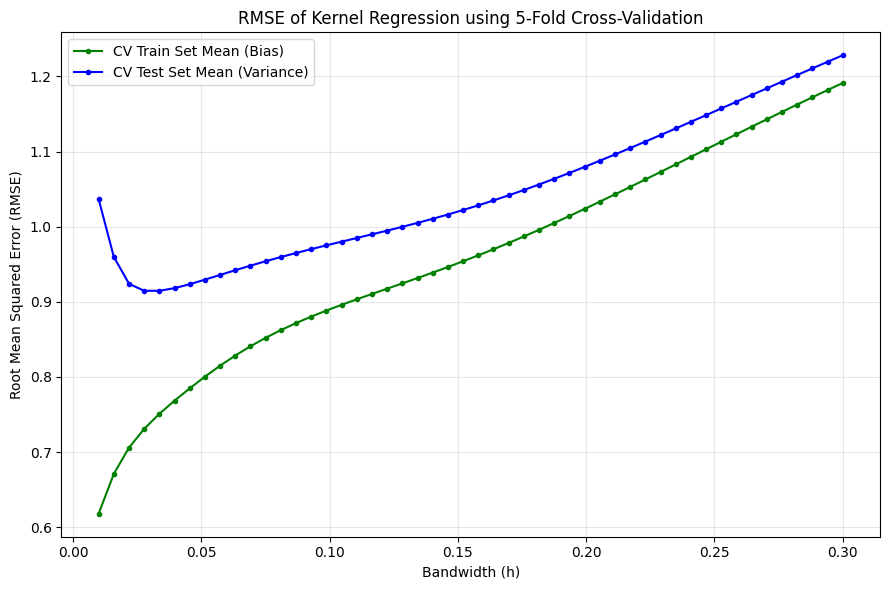

Best bandwidth (h): 0.0337


In [ ]:
# Cv for kernel regression with different bandwidths
bw_list_cv = np.linspace(0.01, 0.3, 50)
rmse_values_train_cv = []
rmse_values_test_cv = []

for bw in bw_list_cv:
    

    model = NadarayaWatson('gaussian', h=bw)

    
    cv_results = cross_validate(
        model, 
        z_sample.reshape(-1, 1), 
        mu_sample, 
        cv=5, 
        scoring='neg_mean_squared_error',
        return_train_score=True
    )
    
    rmse_train_mean = np.sqrt(np.mean(-cv_results['train_score']))
    rmse_test_mean = np.sqrt(np.mean(-cv_results['test_score']))
    
    rmse_values_train_cv.append(rmse_train_mean)
    rmse_values_test_cv.append(rmse_test_mean)

#Plot 
plt.figure(figsize=(9, 6))
plt.plot(bw_list_cv, rmse_values_train_cv, marker='.', linestyle='-', color='green', label='CV Train Set Mean (Bias)')
plt.plot(bw_list_cv, rmse_values_test_cv, marker='.', linestyle='-', color='blue', label='CV Test Set Mean (Variance)')
plt.xlabel('Bandwidth (h)')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('RMSE of Kernel Regression using 5-Fold Cross-Validation')
plt.grid(alpha=0.3, which='both')
plt.legend()
plt.tight_layout()
plt.show()

# Optimal bandwidth
best_bw = bw_list_cv[np.argmin(rmse_values_test_cv)]
print(f"Best bandwidth (h): {best_bw:.4f}")

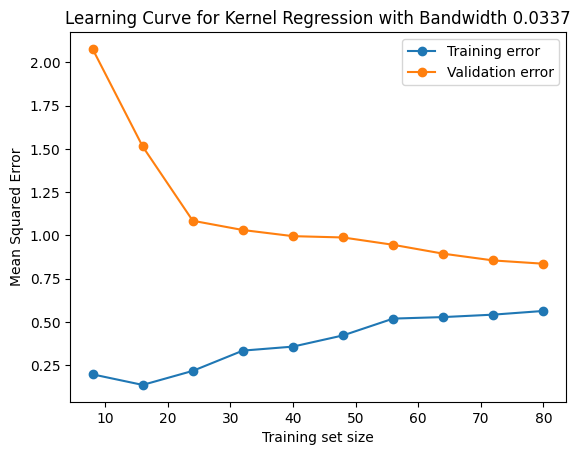

In [ ]:
# Learning curve for the best badwidth
best_model = NadarayaWatson('gaussian', h=best_bw)
train_sizes, train_scores, val_scores = learning_curve(best_model, z_sample.reshape(-1, 1), mu_sample, cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10), random_state=1234)
train_errors = -train_scores.mean(axis=1)
val_errors = -val_scores.mean(axis=1)
plt.figure()    
plt.plot(train_sizes, train_errors, 'o-', label='Training error')
plt.plot(train_sizes, val_errors, 'o-', label='Validation error')
plt.xlabel('Training set size')
plt.ylabel('Mean Squared Error')
plt.title(f'Learning Curve for Kernel Regression with Bandwidth {best_bw:.4f}')
plt.legend()
plt.show()

In [ ]:
# Comparison between the three best models (polynomial, gaussian bases, kernel regression) using the best hyperparameters

# Best Polynomial Model
best_poly_model = PolynomialRegression(degree=best_degree)

#Best Gaussian Basis Model
mu_centers = np.linspace(0, 2, best_n_bases).reshape(-1, 1)
sigma = 2.0 / best_n_bases
custom_basis = partial(gaussian_basis, mu=mu_centers, sigma=sigma)
best_gauss_model = BasisFunctionRegression(basis_func=custom_basis)

#Best Kernel Regression Model
best_kernel_model = NadarayaWatson('gaussian', h=best_bw)


X_data = z_sample.reshape(-1, 1)

best_poly_model.fit(X_data, mu_sample)
best_gauss_model.fit(X_data, mu_sample)
best_kernel_model.fit(X_data, mu_sample)
z_fit = np.linspace(0, 2, 1000).reshape(-1, 1)

mu_poly_fit = best_poly_model.predict(z_fit)
mu_gauss_fit = best_gauss_model.predict(z_fit)
mu_kernel_fit = best_kernel_model.predict(z_fit)


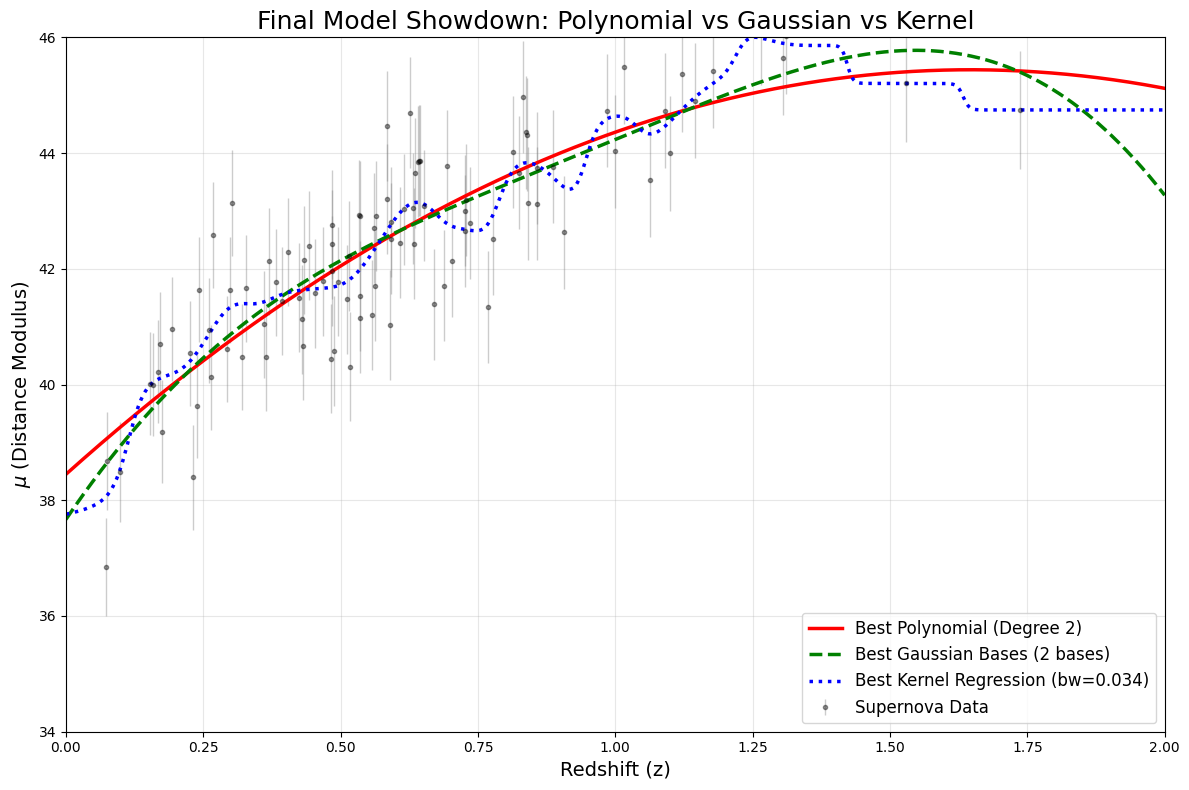

In [ ]:
plt.figure(figsize=(12, 8))

# Plot the original data with error bars
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', 
             lw=1, alpha=0.4, label='Supernova Data')

# Overlay the three best models
plt.plot(z_fit, mu_poly_fit, color='red', lw=2.5, 
         label=f'Best Polynomial (Degree {best_degree})')
plt.plot(z_fit, mu_gauss_fit, color='green', lw=2.5, linestyle='--',
         label=f'Best Gaussian Bases ({best_n_bases} bases)')
plt.plot(z_fit, mu_kernel_fit, color='blue', lw=2.5, linestyle=':',
         label=f'Best Kernel Regression (bw={best_bw:.3f})')

plt.xlabel('Redshift (z)', fontsize=14)
plt.ylabel(r'$\mu$ (Distance Modulus)', fontsize=14)
plt.title('Final Model Showdown: Polynomial vs Gaussian vs Kernel', fontsize=18)
plt.xlim(0, 2)
plt.ylim(34, 46)
plt.grid(alpha=0.3)
plt.legend(loc='lower right', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Calculate the final Root Mean Squared Error on the actual data points
#poly_rmse = np.sqrt(mean_squared_error(mu_sample, best_poly_model.predict(X_data)))
#gauss_rmse = np.sqrt(mean_squared_error(mu_sample, best_gauss_model.predict(X_data)))
#kernel_rmse = np.sqrt(mean_squared_error(mu_sample, best_kernel_model.predict(X_data)))

#print("-" * 40)
#print("FINAL RMSE ON FULL DATASET:")
#print(f"Polynomial Regression: {poly_rmse:.4f}")
#print(f"Gaussian Bases:        {gauss_rmse:.4f}")
#print(f"Kernel Regression:     {kernel_rmse:.4f}")
#print("-" * 40)

# Determine the absolute winner based on the final dataset fit
#errors = {'Polynomial': poly_rmse, 'Gaussian': gauss_rmse, 'Kernel': kernel_rmse}
#winner = min(errors, key=errors.get)

#print(f"\n The best fitting model for this dataset is: {winner.upper()}")